In [1]:
# Name: Leonard Nkholise 
# Date: 28 December 2021
# Date Modified: 13 November 2024
#datasource link: https://royalsocietypublishing.org/doi/10.1098/rspb.2018.2400

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from matplotlib.colors import ListedColormap

### 1.0 Data Reading & Handling 

##### 1.1 Read and assign filtered .csv data into program  

In [2]:
c_data = pd.read_csv("../data/Allometry_all microvelia species.csv")
c_data

,Individuals,Species,Sexe,wing_morph,Total leg length 3,body length
0,1,pulchella,M,wingless,1503.386000,1341.136000
1,2,pulchella,M,wingless,1532.225000,1349.410000
2,3,pulchella,M,wingless,1768.622000,1488.972000
3,8,pulchella,M,wingless,1796.175000,1619.680000
4,9,pulchella,M,wingless,1326.061000,1191.825000
...,...,...,...,...,...,...
268,129,longipes,F,wingless,2662.044374,2080.895224
269,130,longipes,F,wingless,2706.456149,2113.664610
270,131,longipes,F,wingless,3053.442015,2262.229024
271,132,longipes,F,wingless,2697.001779,2109.554107


In [3]:
# Longipes filtered out for distinct, non-overllaping clustering using k-means
c_data=c_data[c_data["Species"]!="longipes"]

In [4]:
x_data = c_data.iloc[:,[4,5]].values # Total leg length 3 and body length
y_data = c_data.loc[:,"Species"].values.reshape(-1,1)

# Split the data into training and testing sets (80% training, 20% testing)
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

In [5]:
# Standardize the features (similar to the classification by sex)
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
X_test_scaled = sc.transform(x_test)

### 2. Hyperperemeter Tunning for KNN

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# KNN init
knn = KNeighborsClassifier(n_neighbors=4)

# Fitting the model on the training data
knn.fit(x_train_scaled, y_train.ravel())

# Predict on the test set
y_pred = knn.predict(X_test_scaled)

print("Accuracy of the KNN classifier: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))

Accuracy of the KNN classifier: 100.00%


In [7]:
# hyperparameter tuning: cross-validation and grid search
from sklearn.model_selection import GridSearchCV

# let's set up a parameter grid for hyperparameter tuning
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  # Testing different values of k
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Testing different distance metrics
}

# Initialize the GridSearchCV object
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1, verbose=1)

# Fitting the model with the best possible params]
grid_search.fit(x_train_scaled, y_train.ravel())

# Get the best parameters and score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: {:.2f}%".format(grid_search.best_score_ * 100))

# Get the best model and make predictions on the test set
best_knn = grid_search.best_estimator_
y_pred_best_knn = best_knn.predict(X_test_scaled)

# Evaluate the accuracy of the best model
print("Accuracy of the best KNN classifier: {:.2f}%".format(accuracy_score(y_test, y_pred_best_knn) * 100))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'metric': 'euclidean', 'n_neighbors': 3}
Best cross-validation score: 99.17%
Accuracy of the best KNN classifier: 100.00%


/home/leonard/miniconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


### 3. Model Validation

In [8]:
# Model validation 
from sklearn.metrics import classification_report, confusion_matrix

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_knn))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_knn))


Classification Report:
              precision    recall  f1-score   support

   americana       1.00      1.00      1.00         9
    cortipes       1.00      1.00      1.00         5
      mimula       1.00      1.00      1.00         3
   pulchella       1.00      1.00      1.00        14

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31


Confusion Matrix:
[[ 9  0  0  0]
 [ 0  5  0  0]
 [ 0  0  3  0]
 [ 0  0  0 14]]


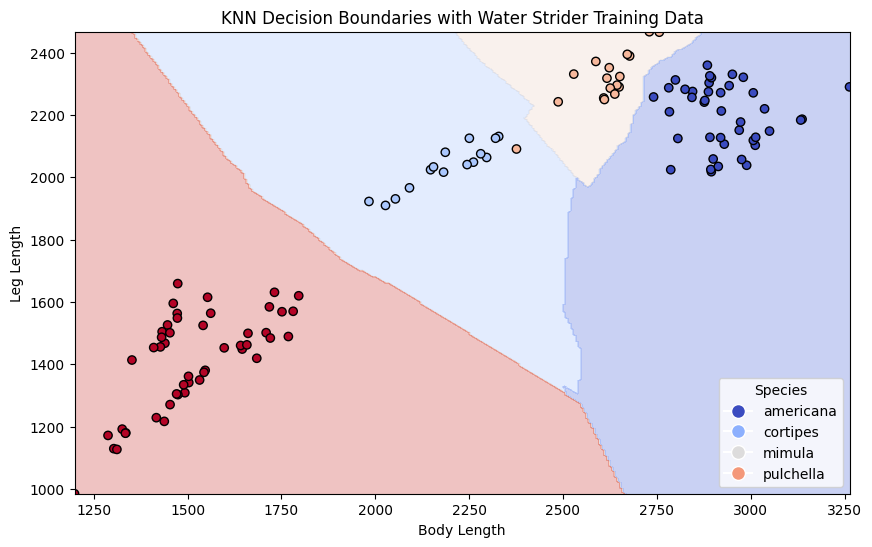

In [9]:
from sklearn.preprocessing import LabelEncoder



# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the training labels to numeric values
y_train_encoded = label_encoder.fit_transform(y_train.ravel())

knn = KNeighborsClassifier(n_neighbors=3, metric= 'euclidean')
knn.fit(x_train, y_train.flatten())

# Predict on the meshgrid for plotting decision boundaries
xx, yy = np.meshgrid(np.linspace(x_train[:, 0].min(), x_train[:, 0].max(), 300),
                     np.linspace(x_train[:, 1].min(), x_train[:, 1].max(), 300))

# Predict the labels for the meshgrid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])

# Label encode the predicted labels
Z_encoded = label_encoder.transform(Z)

# Reshape Z to match the shape of the meshgrid for plotting
Z_encoded = Z_encoded.reshape(xx.shape)

# Plot the decision boundaries
plt.figure(figsize=(10, 6))

# Contour plot to show decision boundaries, using the Z_encoded directly
plt.contourf(xx, yy, Z_encoded, alpha=0.3, cmap='coolwarm')  # Fill the contours

# Scatter plot for the training data, using y_train_encoded for the points
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train_encoded, edgecolors='k', marker='o', cmap='coolwarm')

# Title and labels
plt.title('KNN Decision Boundaries with Water Strider Training Data')
plt.xlabel('Body Length')
plt.ylabel('Leg Length')

unique_labels = np.unique(Z_encoded)
species_names = label_encoder.inverse_transform(unique_labels)

# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.coolwarm(i / len(unique_labels)), markersize=10)
           for i in range(len(unique_labels))]

# Display the legend with species names
plt.legend(handles, species_names, title="Species", loc="lower right")

# Uncomment if you want to save the figure
# plt.savefig("classification.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


### Conclusion

The high cross-validation score of 99.17% for the K-Nearest Neighbors (KNN) model suggests that it is exceptionally effective in classifying different species of water striders based on their body length and leg length. This indicates that the model can accurately distinguish between the various species using these two features, which appear to be reliable identifiers. The well-defined decision boundaries and the model's ability to generalize across different data splits show that the characteristics of the water striders in the dataset are sufficiently distinct for classification. However, it is important to note that the dataset used was relatively small, and for greater reliability and generalization, a larger dataset would be necessary. Furthermore, the model’s performance could be further improved by incorporating additional features beyond body and leg length, such as environmental factors (e.g., water temperature, habitat type), or behavioral characteristics, which could offer more discriminative power. Using a larger and more diverse set of features would provide a more comprehensive understanding of the species’ distinctions and improve the model’s robustness. This result provides confidence that the KNN model could be a valuable tool for classifying water striders in ecological studies, biodiversity monitoring, and field-based species identification, but further testing with a larger and more varied dataset, along with additional relevant features, is recommended for optimal performance.